   ID                      Name Sex   Age  Height  Weight            Team  \
0   1                 A Dijiang   M  24.0   180.0    80.0           China   
1   2                  A Lamusi   M  23.0   170.0    60.0           China   
2   3       Gunnar Nielsen Aaby   M  24.0     NaN     NaN         Denmark   
3   4      Edgar Lindenau Aabye   M  34.0     NaN     NaN  Denmark/Sweden   
4   5  Christine Jacoba Aaftink   F  21.0   185.0    82.0     Netherlands   
5   5  Christine Jacoba Aaftink   F  21.0   185.0    82.0     Netherlands   
6   5  Christine Jacoba Aaftink   F  25.0   185.0    82.0     Netherlands   
7   5  Christine Jacoba Aaftink   F  25.0   185.0    82.0     Netherlands   
8   5  Christine Jacoba Aaftink   F  27.0   185.0    82.0     Netherlands   
9   5  Christine Jacoba Aaftink   F  27.0   185.0    82.0     Netherlands   

   NOC        Games  Year  Season         City          Sport  \
0  CHN  1992 Summer  1992  Summer    Barcelona     Basketball   
1  CHN  2012 Summer  2

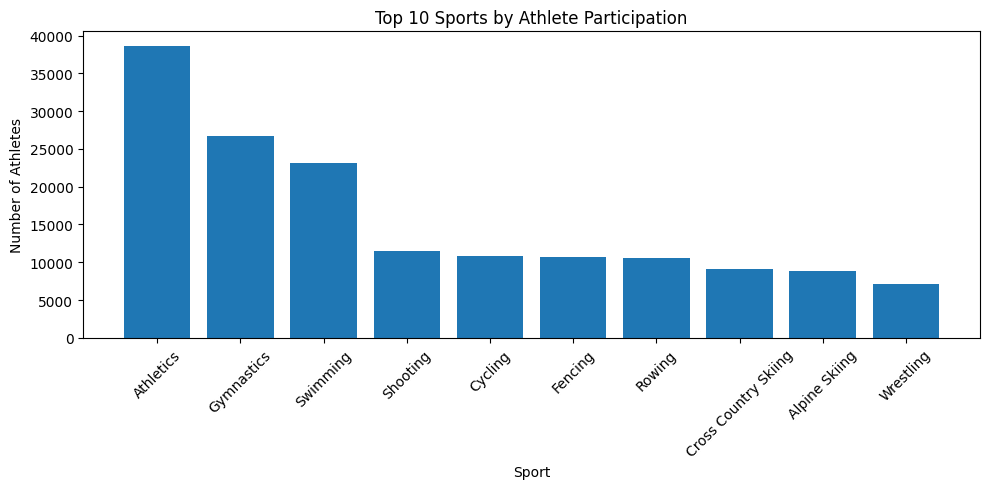

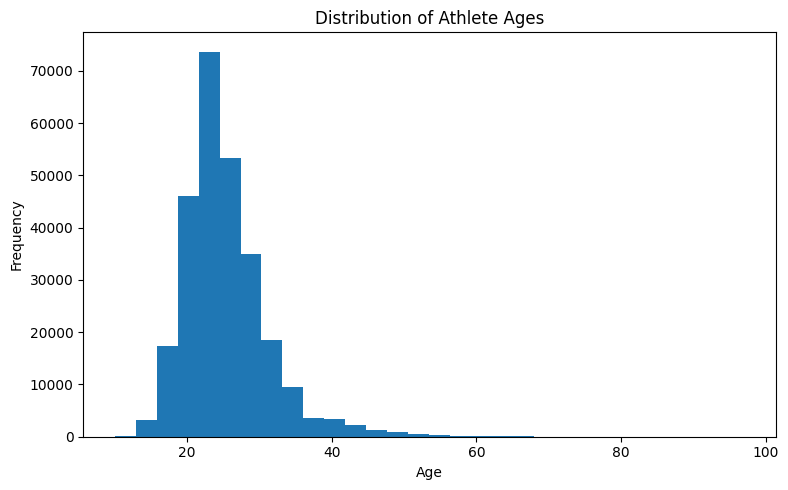

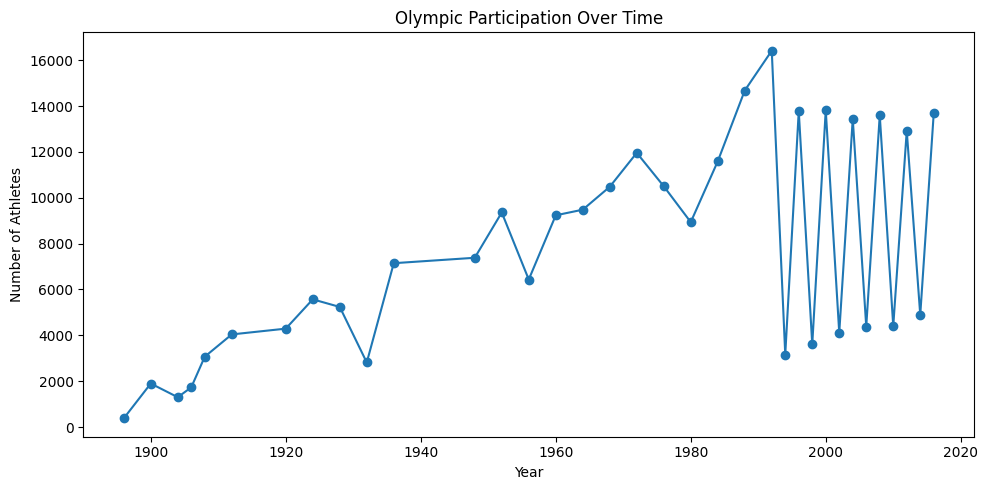

   id   age  height  weight  year  height_m        bmi
0   1  24.0   180.0    80.0  1992      1.80  24.691358
1   2  23.0   170.0    60.0  2012      1.70  20.761246
2   3  24.0   175.0    70.0  1920      1.75  22.857143
3   4  34.0   175.0    70.0  1900      1.75  22.857143
4   5  21.0   185.0    82.0  1988      1.85  23.959094
                id       age    height    weight      year  height_m       bmi
id        1.000000 -0.002580 -0.009612 -0.007715  0.011381 -0.009612 -0.005834
age      -0.002580  1.000000  0.109734  0.165544 -0.073950  0.109734  0.171643
height   -0.009612  0.109734  1.000000  0.786701  0.039883  1.000000  0.312262
weight   -0.007715  0.165544  0.786701  1.000000  0.027158  0.786701  0.824942
year      0.011381 -0.073950  0.039883  0.027158  1.000000  0.039883 -0.022906
height_m -0.009612  0.109734  1.000000  0.786701  0.039883  1.000000  0.312262
bmi      -0.005834  0.171643  0.312262  0.824942 -0.022906  0.312262  1.000000


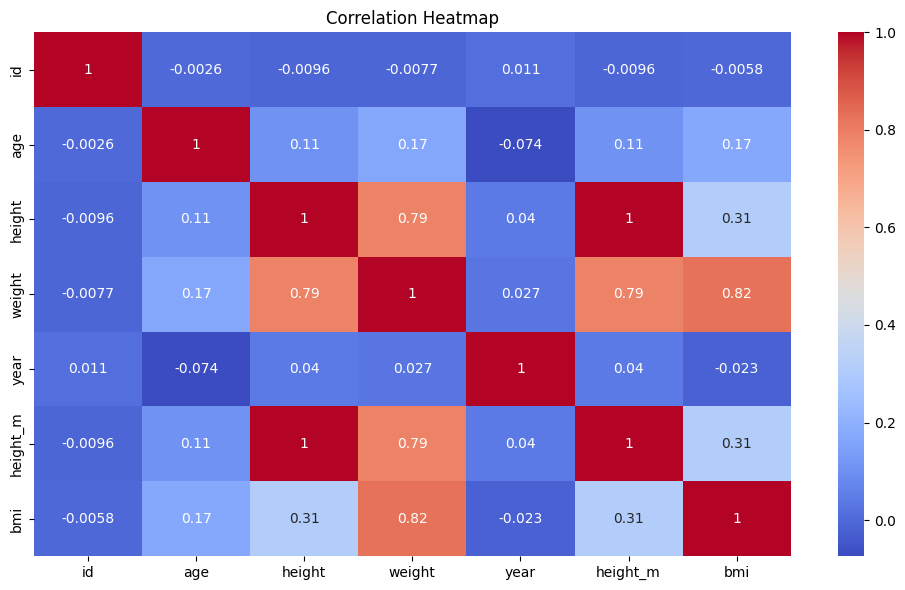

In [26]:
#taskA1
import pandas as pd

df = pd.read_csv('/content/athlete_events.csv.zip',compression='zip')
df.head()
#taskA2
print(df.head(10))
print(df.tail(10))
print(df.shape)
print(df.columns)
print(df.dtypes)
print(df.info())
#taskB1
missing_values = df.isnull().sum()
print(missing_values)

missing_percentage = (df.isnull().sum() / len(df)) * 100
print(missing_percentage)
#taskB2
duplicate_count = df.duplicated().sum()
print("Duplicate rows:", duplicate_count)
#c1 handle missing values
df["Name"] = df["Name"].fillna("Unknown")
df["Age"] = df["Age"].fillna(df["Age"].median())
df["Height"] = df["Height"].fillna(df["Height"].median())
df["Weight"] = df["Weight"].fillna(df["Weight"].median())
df = df.dropna(subset=["ID"])
#c2 remove duplicates
df = df.drop_duplicates()
# Task C3: Standardize Text Columns
text_cols = [
    "Name", "Sex", "Team", "NOC",
    "Games", "Season", "City",
    "Sport", "Event", "Medal"
]
for col in text_cols:
    df[col] = df[col].astype(str).str.strip()

# Convert medal names to title case
df["Medal"] = df["Medal"].str.title()

# Task C4: Convert Data Types
df["ID"] = pd.to_numeric(df["ID"], errors="coerce")
df["Age"] = pd.to_numeric(df["Age"], errors="coerce")
df["Height"] = pd.to_numeric(df["Height"], errors="coerce")
df["Weight"] = pd.to_numeric(df["Weight"], errors="coerce")
df["Year"] = pd.to_numeric(df["Year"], errors="coerce")

# Task C5: Rename Columns
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
)
# Preview cleaned dataset
print(df.head())
# Save cleaned dataset
df.to_csv("cleaned_athlete_events.csv", index=False)

print("Cleaned dataset saved successfully!")

# Check data types
print(df.dtypes)
#Task D1: Summary Statistics
# Numerical columns
print(df.describe())

# Categorical columns
print(df.describe(include="object"))
#Task D2: Value Counts
print("Sport Counts:")
print(df["sport"].value_counts())

print("\nMedal Counts:")
print(df["medal"].value_counts())

print("\nSex Counts:")
print(df["sex"].value_counts())
#Task D3: Filtering
gold_medalists = df[df["medal"] == "Gold"]
print(gold_medalists.head())

older_athletes = df[df["age"] > 30]
print(older_athletes.head())

female_athletes = df[df["sex"] == "F"]
print(female_athletes.head())

indian_athletes = df[df["noc"] == "IND"]
print(indian_athletes.head())
recent_olympics = df[df["year"] >= 2000]
print(recent_olympics.head())
#Task D4: Sorting
top_oldest = df.sort_values(
    by="age",
    ascending=False
).head(10)

print(top_oldest[["name", "age", "sport", "year"]])
top_heaviest = df.sort_values(
    by="weight",
    ascending=False
).head(10)

print(top_heaviest[["name", "weight", "sport"]])
#Task D5: Column Selection
selected_df = df[
    ["name", "sex", "age", "sport", "event", "medal", "year"]
]

print(selected_df.head())
#Part E: Grouping and Aggregation
#single level grouping
sport_summary = df.groupby("sport").agg(
    athlete_count=("id", "count"),
    average_age=("age", "mean"),
    minimum_age=("age", "min"),
    maximum_age=("age", "max")
).reset_index()

print(sport_summary)
#multi level grouping
sport_sex_summary = df.groupby(
    ["sport", "sex"]
).agg(
    athlete_count=("id", "count"),
    average_age=("age", "mean"),
    average_height=("height", "mean"),
    average_weight=("weight", "mean")
).reset_index()

print(sport_sex_summary)
#Task E3: Top 10 Groups
top_10_sports = sport_summary.sort_values(
    by="athlete_count",
    ascending=False
).head(10)

print(top_10_sports)
#Part F: Feature Engineering
#Feature 1: Age Group
df["age_group"] = pd.cut(
    df["age"],
    bins=[0, 18, 30, 45, 60, 100],
    labels=["Teen", "Young Adult", "Adult", "Middle Age", "Senior"]
)

print(df[["age", "age_group"]].head())
#Feature 2: BMI
df["height_m"] = df["height"] / 100

df["bmi"] = df["weight"] / (df["height_m"] ** 2)

print(df[["height", "weight", "bmi"]].head())
#Feature 3: Medal Won
df["medal_status"] = df["medal"].apply(
    lambda x: "Winner" if x != "No Medal" else "Participant"
)

print(df[["medal", "medal_status"]].head())
#Feature 4: Olympic Era
def olympic_era(year):
    if year < 1950:
        return "Early Olympics"
    elif year < 2000:
        return "Modern Olympics"
    else:
        return "Recent Olympics"

df["olympic_era"] = df["year"].apply(olympic_era)
#Part G: Visualization
#Chart 1: Top 10 Sports by Participation
import matplotlib.pyplot as plt

top_sports = (
    df["sport"]
    .value_counts()
    .head(10)
)

plt.figure(figsize=(10,5))
plt.bar(top_sports.index, top_sports.values)
plt.xticks(rotation=45)
plt.title("Top 10 Sports by Athlete Participation")
plt.xlabel("Sport")
plt.ylabel("Number of Athletes")
plt.tight_layout()
plt.show()
#Chart 2: Age Distribution
plt.figure(figsize=(8,5))

plt.hist(
    df["age"].dropna(),
    bins=30
)

plt.title("Distribution of Athlete Ages")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()
#Chart 3: Olympic Participation Trend
yearly_participation = (
    df.groupby("year")
    .size()
    .reset_index(name="athlete_count")
)

plt.figure(figsize=(10,5))

plt.plot(
    yearly_participation["year"],
    yearly_participation["athlete_count"],
    marker="o"
)

plt.title("Olympic Participation Over Time")
plt.xlabel("Year")
plt.ylabel("Number of Athletes")
plt.tight_layout()
plt.show()
#Part H: Correlation Analysis
#H1: Select Numerical Columns
numeric_df = df.select_dtypes(include=["number"])

print(numeric_df.head())
#H2: Correlation Matrix
correlation_matrix = numeric_df.corr()

print(correlation_matrix)
#H3: Heatmap Visualization
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()